In [14]:
using Random
using Printf
using Statistics
using Plots

const SRC = joinpath(@__DIR__, "src")
include(joinpath(SRC, "markov.jl"))
include(joinpath(SRC, "model.jl"))
include(joinpath(SRC, "household.jl"))
include(joinpath(SRC, "simulation.jl"))
include(joinpath(SRC, "regression.jl"))


ols_fit_diagnostics (generic function with 1 method)

## 手順

1. パラメータ $a(A)$, $b(A)$を各$A$について当て推量
2. これらのパラメータから得られる遷移法則を所与として家計の最適化問題を解き、政策関数を得る
3. 適当な状態変数の分布から、政策関数を使って$N$人の$T$期間の貯蓄の推移をシミュレーションする（ただしこのNotebookでは$N=1$）
4. シミュレーションから得られた貯蓄のデータを使って、最小二乗法により$a(A)$, $b(A)$を得る
5. これらのパラメータが当て推量したものと近ければ計算を終え、そうでなければステップ2に戻る

In [2]:
# Outer loop on the perceived forecast rule for log m'.
function solve_ks(mod::Model;
                  a0::Real = 0.095, a1::Real = 0.962,
                  b0::Real = 0.085, b1::Real = 0.965,
                  tol::Real = 1e-7, maxit::Integer = 50_001,
                  lambda::Real = 0.8,
                  seed::Integer = 1234,
                  verbose::Bool = true)
    v0  = ones(mod.Nk, mod.Ne, mod.Nz, mod.Nm)
    mu0 = ones(mod.Nk_dist, mod.Ne) ./ (mod.Nk_dist * mod.Ne)
    z_sim_index, _ = simulate_aggregate_shock(mod.zgrid, mod.pi_z, mod.T_sim;
                                              rng = MersenneTwister(seed))

    diff_params = 1.0
    iter = 0
    v = v0
    g = similar(v0)
    while diff_params > tol && iter < maxit
        iter += 1
        v, g, _  = solve_household(mod, a0, a1, b0, b1, v0)
        kbar_sim = simulate_capital_path(mod, g, z_sim_index, mu0)
        a0_hat, a1_hat, b0_hat, b1_hat = ols_forecast_rule(mod, kbar_sim, z_sim_index)

        diff_params = max(abs(a0 - a0_hat), abs(a1 - a1_hat),
                          abs(b0 - b0_hat), abs(b1 - b1_hat))

        if verbose
            @printf("%4d  a=[% .6f, % .6f]  b=[% .6f, % .6f]  diff=%.3e\n",
                    iter, a0, a1, b0, b1, diff_params)
            flush(stdout)
        end

        a0 = lambda * a0 + (1 - lambda) * a0_hat
        a1 = lambda * a1 + (1 - lambda) * a1_hat
        b0 = lambda * b0 + (1 - lambda) * b0_hat
        b1 = lambda * b1 + (1 - lambda) * b1_hat
        v0 = v
    end

    return (a0 = a0, a1 = a1, b0 = b0, b1 = b1,
            v = v, g = g,
            z_sim_index = z_sim_index, mu0 = mu0, iter = iter)
end

solve_ks (generic function with 1 method)

In [6]:
mod = Construct()
println("=== Krusell & Smith (1998) ===")
println("[iter, a0, a1, b0, b1, diff]")
flush(stdout)

@time res = solve_ks(mod)

# Diagnostics at the converged forecast rule.
kbar_sim = simulate_capital_path(mod, res.g, res.z_sim_index, res.mu0)
a0h, a1h, b0h, b1h = ols_forecast_rule(mod, kbar_sim, res.z_sim_index)
R2g, R2b, sig2g, sig2b = ols_fit_diagnostics(mod, kbar_sim, res.z_sim_index,
                                                a0h, a1h, b0h, b1h)
println()
println("R^2  good = ", R2g)
println("R^2  bad  = ", R2b)
println("sigma good = ", sqrt(sig2g) * 100, " %")
println("sigma bad  = ", sqrt(sig2b) * 100, " %")


=== Krusell & Smith (1998) ===
[iter, a0, a1, b0, b1, diff]
   1  a=[ 0.095000,  0.962000]  b=[ 0.085000,  0.965000]  diff=2.160e-03
   2  a=[ 0.094587,  0.962170]  b=[ 0.084568,  0.964926]  diff=3.003e-03
   3  a=[ 0.093986,  0.962473]  b=[ 0.083970,  0.965034]  diff=2.507e-03
   4  a=[ 0.093506,  0.962733]  b=[ 0.083468,  0.965152]  diff=1.775e-03
   5  a=[ 0.093170,  0.962924]  b=[ 0.083113,  0.965236]  diff=1.175e-03
   6  a=[ 0.092944,  0.963061]  b=[ 0.082878,  0.965286]  diff=7.537e-04
   7  a=[ 0.092793,  0.963157]  b=[ 0.082728,  0.965312]  diff=5.007e-04
   8  a=[ 0.092693,  0.963224]  b=[ 0.082635,  0.965323]  diff=3.334e-04
   9  a=[ 0.092627,  0.963272]  b=[ 0.082579,  0.965325]  diff=2.231e-04
  10  a=[ 0.092582,  0.963306]  b=[ 0.082547,  0.965322]  diff=1.506e-04
  11  a=[ 0.092552,  0.963331]  b=[ 0.082529,  0.965317]  diff=1.027e-04
  12  a=[ 0.092531,  0.963349]  b=[ 0.082521,  0.965310]  diff=7.105e-05
  13  a=[ 0.092517,  0.963363]  b=[ 0.082518,  0.965304]  diff=4

## Den Haan test

近似集計の精度を測る方法として、Den Hann (2010)の提案したテストがある。
このテストでは、

- 政策関数にしたがってシミュレーションされた総資産（上の`simulate_capital_path`で得られるもの）
- 近似集計による遷移式からシミュレーションされる総資産

の二つが近いかどうかをチェックする。
前者は状態変数の分布をもとに得られるもので、後者はそれをうまく近似できていることが期待される。

In [7]:
# Forecast vs simulated path under the converged rule (den Haan diagnostic).
function den_haan_test(mod::Model, kbar_sim::AbstractVector,
                       z_sim_index::AbstractVector,
                       a0::Real, a1::Real, b0::Real, b1::Real)
    T_post = mod.T_sim - mod.T0
    kbar_forecast = zeros(T_post)
    kbar_forecast[1] = kbar_sim[1]
    for t in 1:T_post - 1
        if z_sim_index[mod.T0 + t] == 1.0
            kbar_forecast[t + 1] = exp(b0 + b1 * log(kbar_forecast[t]))
        else
            kbar_forecast[t + 1] = exp(a0 + a1 * log(kbar_forecast[t]))
        end
    end
    errors = abs.((kbar_sim .- kbar_forecast) ./ kbar_forecast)
    return kbar_forecast, mean(errors) * 100, maximum(errors) * 100
end


den_haan_test (generic function with 1 method)

In [9]:
kbar_forecast, mean_err, max_err = den_haan_test(mod, kbar_sim, res.z_sim_index,
                                        a0h, a1h, b0h, b1h)
println("den Haan mean error = ", mean_err, " %")
println("den Haan max  error = ", max_err,  " %")

den Haan mean error = 0.05177381377089429 %
den Haan max  error = 0.24237265052214052 %


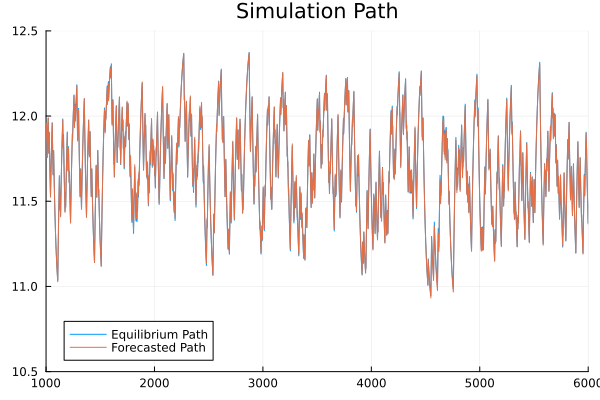

In [20]:
plot(mod.T0+1:mod.T_sim, kbar_sim, label="Equilibrium Path")
plot!(mod.T0+1:mod.T_sim, kbar_forecast, label="Forecasted Path")
xlims!(mod.T0,mod.T_sim)
ylims!(10.5,12.5)
title!("Simulation Path")